In [1]:
import os

# change directory one up 
os.chdir('..')


In [52]:
import importlib
import utils
importlib.reload(utils)
from notebooks.utils import *

['test_clicks_param_shift_0.0_idx2.csv', 'test_clicks_param_shift_-1.5_idx11.csv', 'test_clicks_param_shift_-3.0_idx17.csv', 'test_clicks_param_shift_-3.0_idx16.csv', 'test_clicks_param_shift_-1.5_idx10.csv', 'test_clicks_param_shift_0.0_idx3.csv', 'test_clicks_param_shift_0.0_idx1.csv', 'test_clicks_param_shift_-1.5_idx12.csv', 'test_clicks_param_shift_-3.0_idx14.csv', 'test_clicks_param_shift_-3.0_idx15.csv', 'test_clicks_param_shift_-1.5_idx13.csv', 'test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_0.0_idx4.csv', 'test_clicks_param_shift_-1.5_idx17.csv', 'test_clicks_param_shift_-3.0_idx11.csv', 'test_clicks_param_shift_-3.0_idx10.csv', 'test_clicks_param_shift_-1.5_idx16.csv', 'test_clicks_param_shift_0.0_idx5.csv', 'test_clicks_param_shift_0.0_idx7.csv', 'test_clicks_param_shift_0.0_idx18.csv', 'test_clicks_param_shift_3.0_idx9.csv', 'test_clicks_param_shift_-1.5_idx14.csv', 'test_clicks_param_shift_-3.0_idx12.csv', 'test_clicks_param_shift_-1.5_idx9.csv', 'test_cli

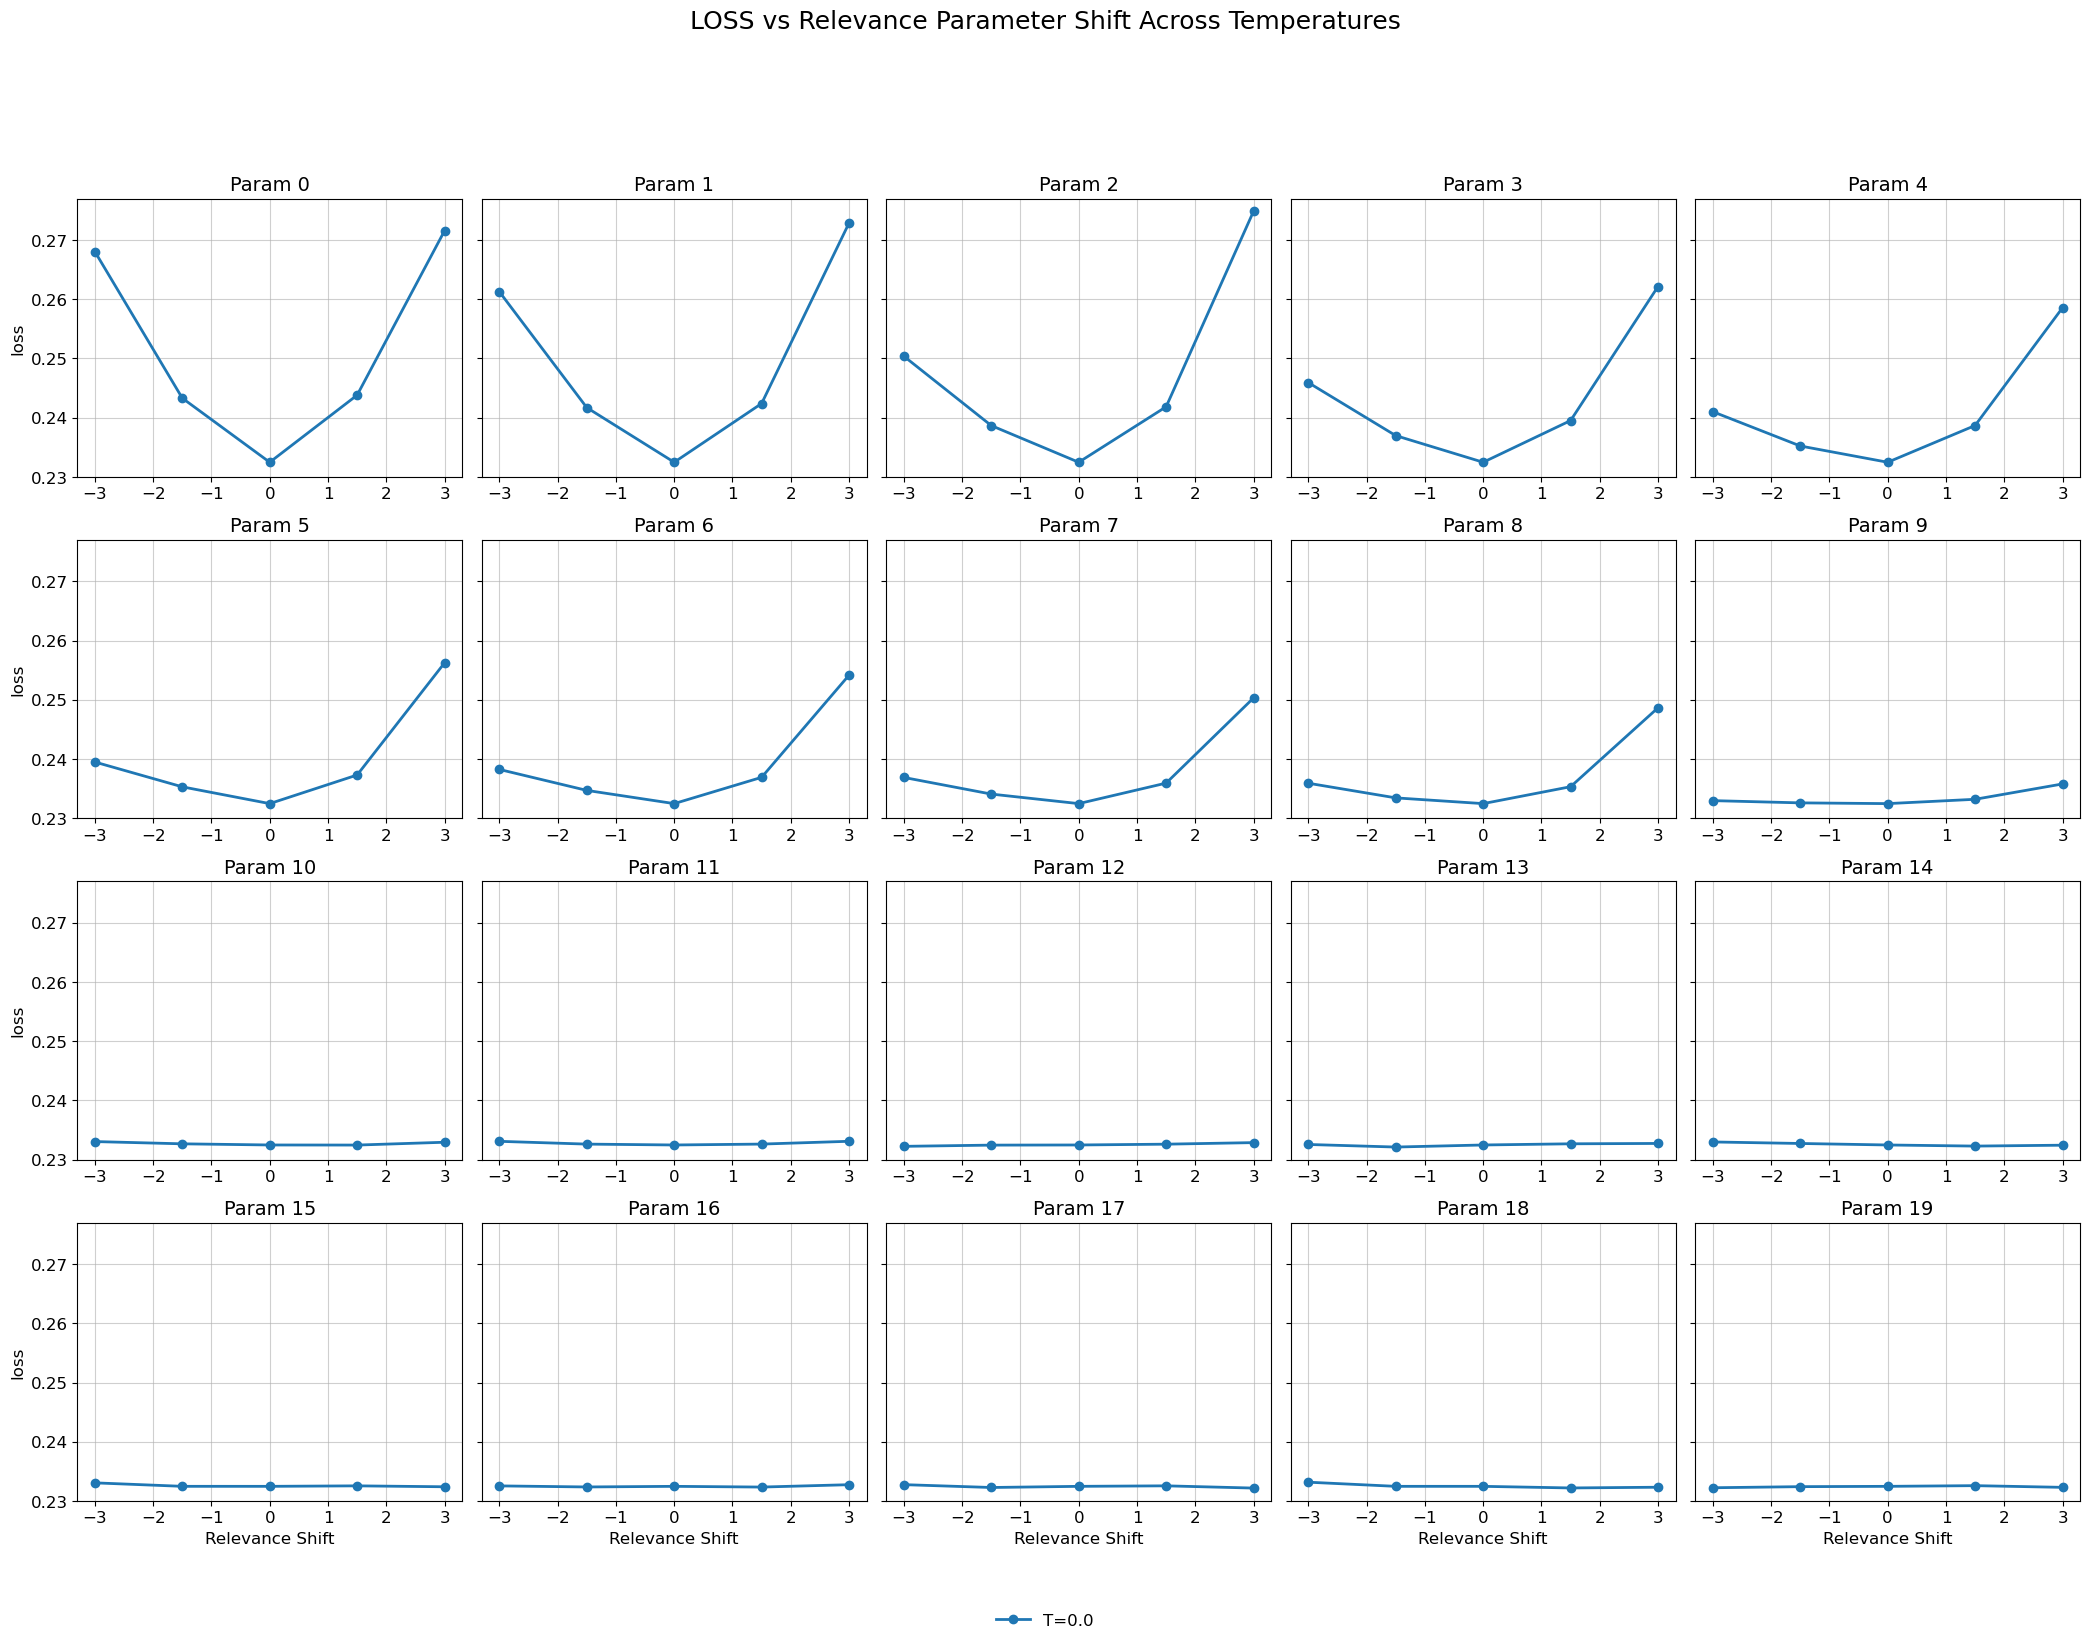

In [53]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

folder_path = "results/test_baidu/data=Custom_dataset_deep,experiment=test_baidu,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"

# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx'
)

# Load relevance
rel_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_relevance,
    'relevance_shift',
    'param_idx'
)


# ✅ Now you can plot, just reversing the meaning of the axes
# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, doc_group_sizes, temperatures)
plot_performance_grid_all_temps([perf_df], [0.0], metric='loss')

In [54]:
perf_df

,nll,loss,relevance_shift,param_idx
0,0.268034,0.268034,-3.0,0
0,0.243290,0.243290,-1.5,0
0,0.232464,0.232464,0.0,0
0,0.243799,0.243799,1.5,0
0,0.271556,0.271556,3.0,0
...,...,...,...,...
0,0.232226,0.232226,-3.0,19
0,0.232410,0.232410,-1.5,19
0,0.232464,0.232464,0.0,19
0,0.232580,0.232580,1.5,19


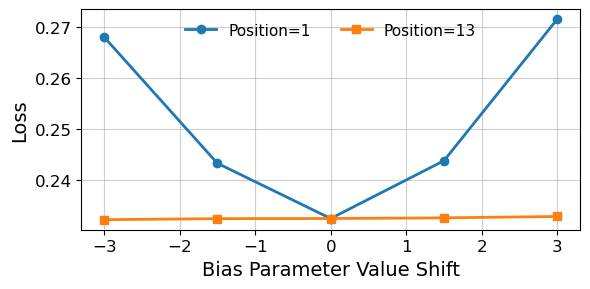

In [55]:
import matplotlib.pyplot as plt

params_to_plot = [0, 12]

fig, ax = plt.subplots(figsize=(6, 3))

for param_idx, linestyle, marker in zip(params_to_plot, ['-', '-'], ['o', 's']):
    ax.plot(
        perf_df[perf_df['param_idx'] == param_idx]['relevance_shift'],
        perf_df[perf_df['param_idx'] == param_idx]['loss'],
        linestyle=linestyle,
        marker=marker,
        linewidth=2,
        label=f'Position={param_idx+1}'
    )

ax.set_xlabel('Bias Parameter Value Shift', fontsize=14)
ax.set_ylabel('Loss', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.6)

ax.legend(fontsize=11, frameon=False, ncol=2, loc='upper center')
plt.tight_layout()
plt.savefig("notebooks/plots/Real_world_front_page_example.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [56]:
data = np.load("../ltr_datasets/train_Baidu_ULTRA_part1.npz", allow_pickle=True)
padded_positions = data['padded_positions']
counts = np.sum(padded_positions != -1, axis=0)
perf_df["sample_count"] = perf_df["param_idx"].map(
    {i: count for i, count in enumerate(counts)}
)

In [57]:
print(counts)

[500218 486031 515128 514036 519158 524814 549096 521379 556559  68571
  24396  22515  16248  11565   7040   3907   2119   1345    619     27]


In [58]:
import matplotlib.pyplot as plt
import numpy as np

def plot_performance_by_param(
    df,
    metric='loss',
    diff_from_zero=False,
    with_comparison=True,
    max_cols=5
):
    required_cols = {'relevance_shift', 'param_idx', metric, 'sample_count'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Missing columns: {required_cols - set(df.columns)}")

    param_values = sorted(df['param_idx'].unique())
    n_params = len(param_values)

    # --- Compute grid size ---
    n_cols = min(max_cols, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3.2 * n_rows),
        sharey=True
    )

    # Ensure axes is always 2D array
    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes.reshape(n_rows, 1)

    first_ax = [axes[i][0] for i in range(n_rows)]
    all_y_values = []

    # Colors
    tab10 = plt.get_cmap('tab10').colors
    desired_colors = ['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']
    color_sequence = desired_colors + [c for c in tab10 if c not in desired_colors]
    color_map = {param: color_sequence[i % len(color_sequence)] for i, param in enumerate(param_values)}

    # Comparison lines
    COMPARISON_LINES = [
        (2.71, 'p=0.10'),
        (3.84, 'p=0.05'),
        (6.63, 'p=0.01'),
        (10.83, 'p=0.001')
    ]

    # --- Loop over grid ---
    for idx, param in enumerate(param_values):
        r = idx // n_cols
        c = idx % n_cols
        ax = axes[r][c]

        sub_p = df[df["param_idx"] == param].sort_values("relevance_shift")
        if sub_p.empty:
            ax.axis("off")
            continue

        # Compute y-values
        if diff_from_zero:
            baseline_vals = sub_p.loc[sub_p["relevance_shift"] == 0, metric]
            if baseline_vals.empty:
                baseline = sub_p.iloc[(sub_p["relevance_shift"] - 0).abs().idxmin()][metric]
            else:
                baseline = baseline_vals.mean()

            # Multiply per row by sample_count
            y_values = (sub_p[metric] - baseline) * sub_p['sample_count']
            label = f"Param {param} (Δ × samples)"
        else:
            y_values = sub_p[metric]
            label = f"Param {param}"

        color = color_map[param]

        ax.plot(
            sub_p["relevance_shift"],
            y_values,
            marker="o", lw=2,
            color=color,
            label=label
        )

        all_y_values.extend(np.asarray(y_values).tolist())
        ax.set_title(f"Param {param}", fontsize=10)
        ax.set_xlabel("Bias Shift ($s$)")

        # Only first subplot shows y-axis labels
        if ax in first_ax:
            y_label = metric if not diff_from_zero else f"Δ {metric} × samples"
            ax.set_ylabel(y_label)
        else:
            ax.tick_params(labelleft=False)

        # --- Comparison lines ---
        if with_comparison:
            xmin, xmax = ax.get_xlim()
            for yval, txt in COMPARISON_LINES:
                ax.axhline(y=yval, color="black", linestyle="--", lw=1.1)
                ax.text(
                    xmax * 0.98, yval + 0.05,
                    txt,
                    fontsize=8, ha="right", va="bottom",
                    backgroundcolor="white"
                )

        # Legend
        ax.legend(frameon=False, fontsize=8, loc="upper left")

    # Turn off unused axes
    total_cells = n_rows * n_cols
    for empty_idx in range(n_params, total_cells):
        r = empty_idx // n_cols
        c = empty_idx % n_cols
        axes[r][c].axis("off")

    # --- Shared y-limits ---
    if all_y_values:
        margin = max(np.std(all_y_values) * 1.1, 0.1)
        ymin, ymax = min(all_y_values) - margin, max(all_y_values) + margin
        ymax = 16
        ymin = max(ymin, -1.5)
        for ax in first_ax:
            ax.set_ylim(ymin, ymax)

    # Fix whitespace
    fig.subplots_adjust(
        top=0.92,
        bottom=0.12,
        left=0.07,
        right=0.98,
        wspace=0.15,
        hspace=0.35
    )

    plt.show()


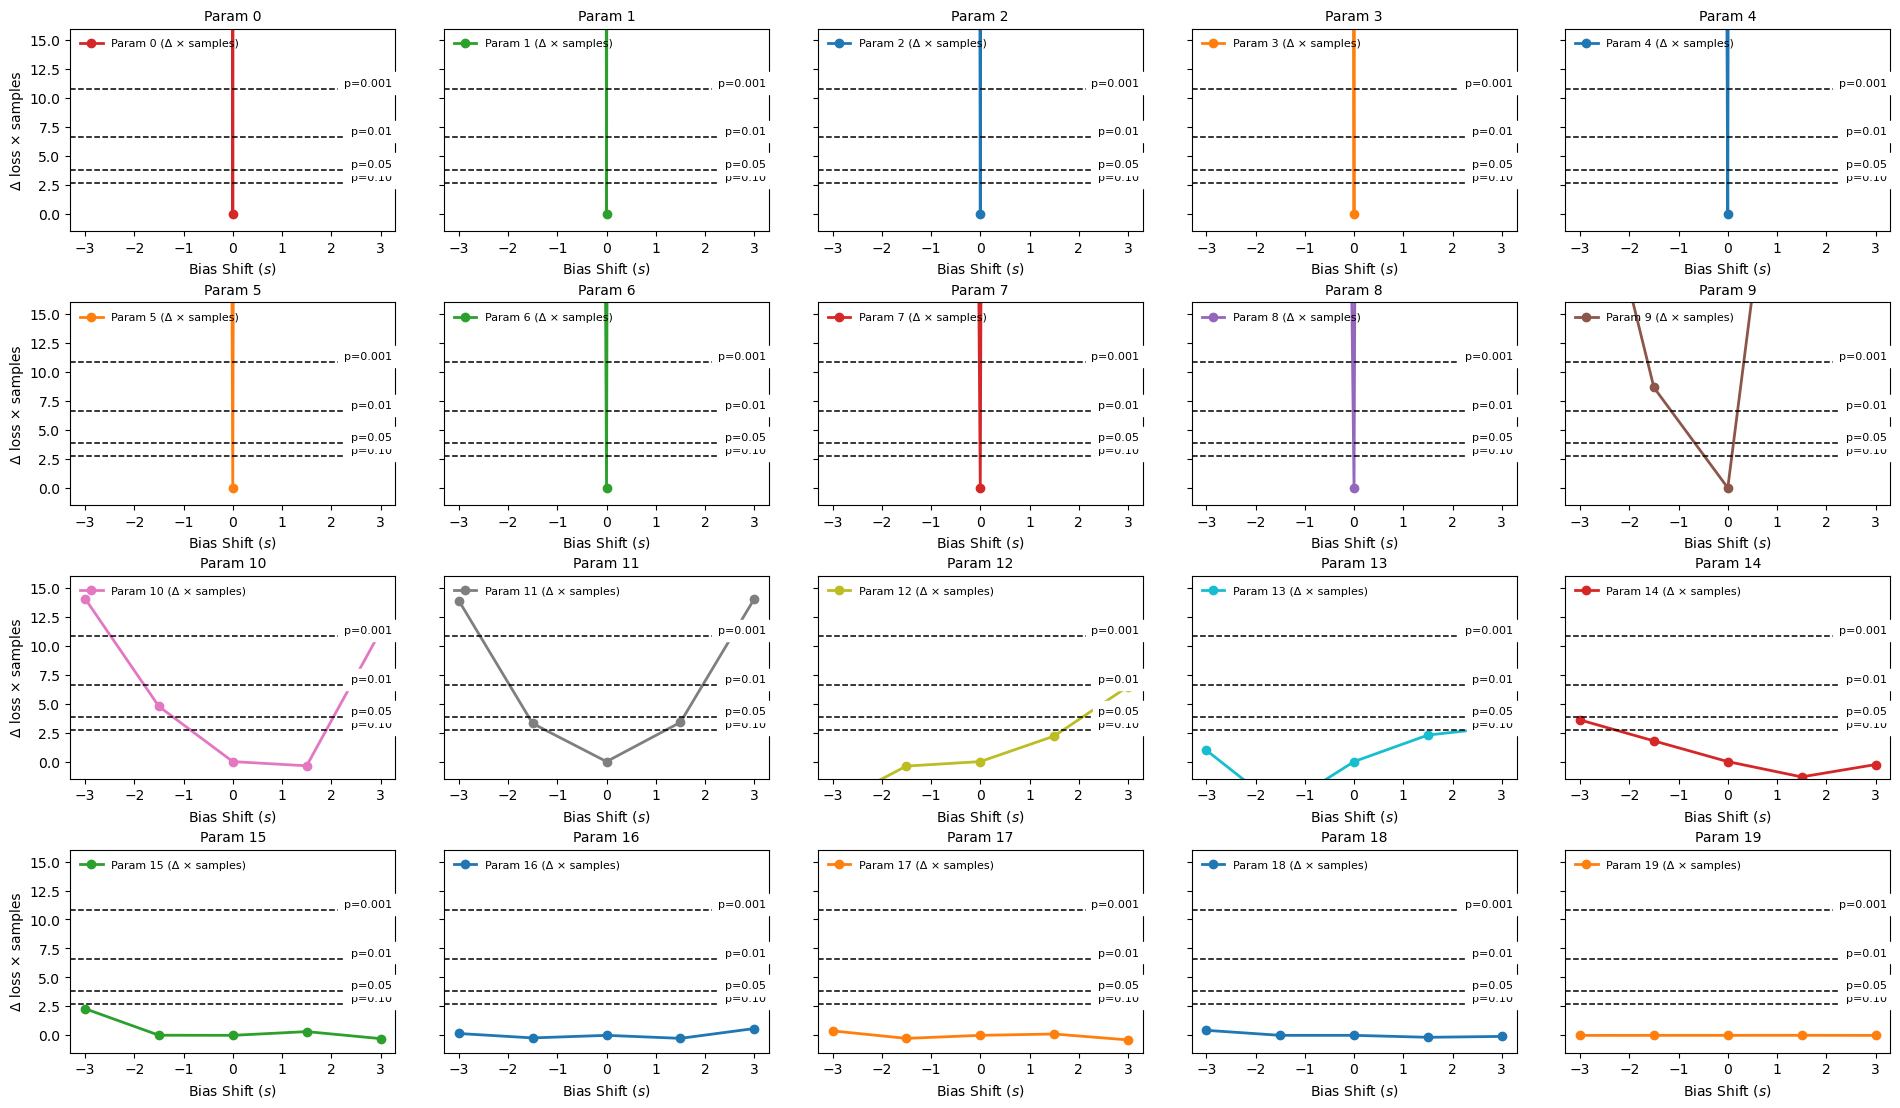

In [59]:
plot_performance_by_param(perf_df, metric="loss", diff_from_zero=True, with_comparison=True)


In [60]:
perf_df

,nll,loss,relevance_shift,param_idx,sample_count
0,0.268034,0.268034,-3.0,0,500218
0,0.243290,0.243290,-1.5,0,500218
0,0.232464,0.232464,0.0,0,500218
0,0.243799,0.243799,1.5,0,500218
0,0.271556,0.271556,3.0,0,500218
...,...,...,...,...,...
0,0.232226,0.232226,-3.0,19,27
0,0.232410,0.232410,-1.5,19,27
0,0.232464,0.232464,0.0,19,27
0,0.232580,0.232580,1.5,19,27


In [61]:
from scipy.stats import chi2

# Compute global delta loss first
baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]
def compute_identifiability(df, thresholds=[0.05, 0.001, 0.0001]):
    required = {
        'relevance_shift', 'param_idx', 'loss',
        'sample_count', 'delta_loss', 'delta_loss_times_samples'
    }
    if not required.issubset(df.columns):
        raise ValueError(f"Missing columns: {required - set(df.columns)}")

    chi2_critical = {thr: chi2.ppf(1 - thr, df=1) for thr in thresholds}

    # Precompute minimal p-value per row
    df = df.copy()
    df["min_pval"] = np.inf
    for thr, crit in chi2_critical.items():
        mask = df["delta_loss_times_samples"] >= crit
        df.loc[mask, "min_pval"] = np.minimum(df.loc[mask, "min_pval"], thr)

    def first_identifiable(sub, sign):
        s = sub[sub["relevance_shift"] * sign > 0]
        if s.empty:
            return None, None
        s = s.sort_values("relevance_shift", ascending=(sign > 0))
        s = s[s["min_pval"] < np.inf]
        if s.empty:
            return None, None
        row = s.iloc[0]
        return row["min_pval"], row["relevance_shift"]

    results = {}

    print(f"{'Param':>5} | {'Neg p':>7} | {'Neg Δ':>7} | {'Pos Δ':>7} | "
          f"{'Avg ΔLoss':>10} | {'Samples':>8} | {'Conclusion':>22}")
    print("-" * 95)

    for param, sub in df.groupby("param_idx"):
        neg_thr, neg_shift = first_identifiable(sub, sign=-1)
        pos_thr, pos_shift = first_identifiable(sub, sign=+1)

        avg_delta = (
            sub["delta_loss_times_samples"].sum() /
            sub["sample_count"].sum()
        )
        total_samples = sub["sample_count"].sum()

        if neg_thr is None and pos_thr is None:
            conclusion = "unidentified"
        elif neg_thr is not None and pos_thr is not None:
            conclusion = "identified"
        else:
            conclusion = "practically unidentified"

        results[param] = (
            (neg_thr, pos_thr),
            (neg_shift, pos_shift),
            avg_delta,
            total_samples,
            conclusion
        )

        print(f"{param:>5} | {str(neg_thr):>7} | {str(neg_shift):>7} | "
              f"{str(pos_shift):>7} | {avg_delta:>10.6f} | "
              f"{total_samples:>8} | {conclusion:>22}")

    return results

# Usage
identifiability_results = compute_identifiability(perf_df, thresholds=[0.05, 0.001, 0.0001])


Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     1.5 |   0.019365 |  2501090 |             identified
    1 |  0.0001 |    -1.5 |     1.5 |   0.017669 |  2430155 |             identified
    2 |  0.0001 |    -1.5 |     1.5 |   0.015169 |  2575640 |             identified
    3 |  0.0001 |    -1.5 |     1.5 |   0.010933 |  2570180 |             identified
    4 |  0.0001 |    -1.5 |     1.5 |   0.008716 |  2595790 |             identified
    5 |  0.0001 |    -1.5 |     1.5 |   0.007692 |  2624070 |             identified
    6 |  0.0001 |    -1.5 |     1.5 |   0.006827 |  2745480 |             identified
    7 |  0.0001 |    -1.5 |     1.5 |   0.005467 |  2606895 |             identified
    8 |  0.0001 |    -1.5 |     1.5 |   0.004690 |  2782795 |             identified
    9 |    0.05 |    -1.5 |     1.5 |   0.000936 |   3

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_15229/3128420778.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = cm.get_cmap("tab10")


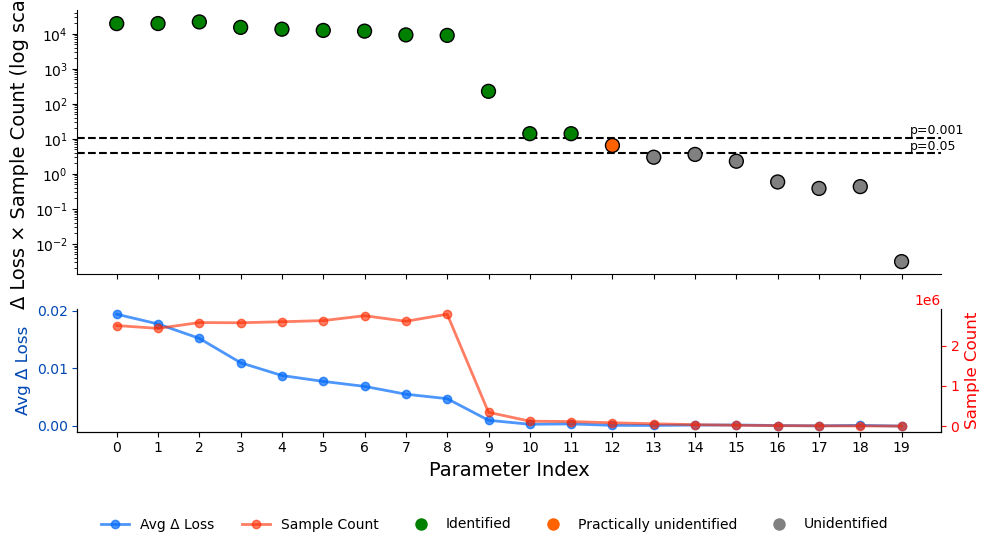

In [62]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from matplotlib import cm

tab10 = cm.get_cmap("tab10")

# Extract data per parameter
params = sorted(identifiability_results.keys())
avg_delta_loss = [identifiability_results[p][2] for p in params]
sample_counts = [identifiability_results[p][3] for p in params]
conclusions = [identifiability_results[p][4].strip().lower() for p in params]

# Δ Loss × Sample Count
delta_loss_times_samples = (
    perf_df.groupby("param_idx")["delta_loss"].max()
    * perf_df.groupby("param_idx")["sample_count"].mean()
)
delta_loss_times_samples = [delta_loss_times_samples.get(p, 0) for p in params]

# Brighter color choices for labels & lines
avg_loss_color = "#046BFAB5"     # bright blue
sample_count_color = "#FF2A009C" # bright red
avg_loss_text_color = "#0047B3" # darker blue
sample_count_text_color = "#FF0000" # darker red

color_map = {
    "identified": "green",
    "practically unidentified": "#FF6200",
    "unidentified": "gray"
}
dot_colors = [color_map[c] for c in conclusions]

# Threshold lines
COMPARISON_LINES = [
    (3.84, 'p=0.05'),
    (10.83, 'p=0.001'),
]
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(10, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.4]}
)

# =========================
# TOP: Δ Loss × Sample Count
# =========================
ax_top.scatter(
    params,
    delta_loss_times_samples,
    color=dot_colors,
    edgecolor="black",
    s=100,
    zorder=3
)

ax_top.set_yscale("log")
ax_top.set_ylabel("Δ Loss × Sample Count (log scale)", fontsize=14)

for yval, label in COMPARISON_LINES:
    ax_top.axhline(y=yval, color="black", ls="--", lw=1.5, zorder=1)
    ax_top.text(
        max(params) * 1.01, yval * 1.05,
        label, ha="left", va="bottom", fontsize=9
    )

ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)


# =========================
# BOTTOM: Dual-axis lines
# =========================
# Left axis: Avg Δ Loss
ax_bottom.plot(
    params,
    avg_delta_loss,
    color=avg_loss_color,
    marker="o",
    linewidth=2,
    label="Avg Δ Loss"
)
ax_bottom.set_ylabel("Avg Δ Loss", color=avg_loss_text_color, fontsize=12)
ax_bottom.tick_params(axis="y", colors=avg_loss_text_color)

# Right axis: Sample Count
ax_bottom_r = ax_bottom.twinx()
ax_bottom_r.plot(
    params,
    sample_counts,
    color=sample_count_color,
    marker="o",
    linewidth=2,
    label="Sample Count"
)
ax_bottom_r.set_ylabel("Sample Count", color=sample_count_text_color, fontsize=12)
ax_bottom_r.tick_params(axis="y", colors=sample_count_text_color)

ax_bottom.set_xlabel("Parameter Index", fontsize=14)
ax_bottom.set_xticks(params)

ax_bottom.spines["top"].set_visible(False)
ax_bottom_r.spines["top"].set_visible(False)


# =========================
# LEGEND
# =========================
legend_elements = [
    Line2D([0], [0], color=avg_loss_color, lw=2, marker="o",
           label="Avg Δ Loss"),
    Line2D([0], [0], color=sample_count_color, lw=2, marker="o",
           label="Sample Count"),
] + [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=color, markersize=10,
           label=label.capitalize())
    for label, color in color_map.items()
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(legend_elements),
    frameon=False
)

plt.tight_layout()
plt.show()


/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_15229/2299770791.py:271: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


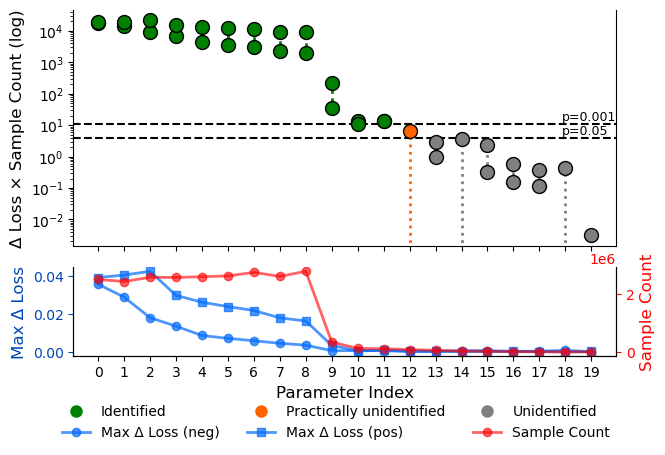

In [63]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import cm
import numpy as np


def plot_identifiability_summary(
    identifiability_results,
    perf_df,
    *,
    output_path=None,
    figsize=(7, 4.5),
    comparison_lines=((3.84, "p=0.05"), (10.83, "p=0.001")),
    color_map=None,
    avg_loss_color="#046BFAB5",
    sample_count_color="#FF00009C",
    avg_loss_text_color="#0047B3",
    sample_count_text_color="#FF0000",
):
    """
    Plot identifiability summary with:
      1) Signed (Δ Loss × Sample Count) on log scale (top panel)
      2) Max Δ Loss (neg/pos) and Sample Count context (bottom panel)

    Parameters
    ----------
    identifiability_results : dict
        Mapping param_idx -> tuple where:
            [2] = avg delta loss
            [3] = sample count
            [4] = identifiability conclusion (string)

    perf_df : pandas.DataFrame
        Must contain columns:
            - param_idx
            - relevance_shift (signed)
            - delta_loss
            - sample_count

    output_path : str or None, optional
        If provided, saves figure to this path.

    figsize : tuple, optional
        Figure size.

    comparison_lines : iterable of (float, str), optional
        Horizontal reference lines for Δ loss × sample count.

    color_map : dict or None, optional
        Mapping conclusion -> color.
        Defaults to:
            {
                "identified": "green",
                "practically unidentified": "#FF6200",
                "unidentified": "gray"
            }

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : tuple(matplotlib.axes.Axes, matplotlib.axes.Axes)
        (ax_top, ax_bottom)
    """

    if color_map is None:
        color_map = {
            "identified": "green",
            "practically unidentified": "#FF6200",
            "unidentified": "gray",
        }

    # -----------------------
    # Extract per-parameter data
    # -----------------------
    params = sorted(identifiability_results.keys())

    sample_counts = [identifiability_results[p][3] for p in params]
    conclusions = [identifiability_results[p][4].strip().lower() for p in params]
    dot_colors = [color_map[c] for c in conclusions]

    # -----------------------
    # Δ Loss × Sample Count (signed)
    # -----------------------
    neg_df = perf_df[perf_df["relevance_shift"] < 0]
    pos_df = perf_df[perf_df["relevance_shift"] > 0]

    delta_loss_times_samples_neg = (
        neg_df.assign(stat=lambda d: d.delta_loss * d.sample_count)
            .groupby("param_idx")["stat"]
            .max()
    )

    delta_loss_times_samples_pos = (
        pos_df.assign(stat=lambda d: d.delta_loss * d.sample_count)
            .groupby("param_idx")["stat"]
            .max()
    )
    delta_loss_times_samples_neg = [
        delta_loss_times_samples_neg.get(p, 0) for p in params
    ]
    delta_loss_times_samples_pos = [
        delta_loss_times_samples_pos.get(p, 0) for p in params
    ]

    # -----------------------
    # Max Δ Loss (context)
    # -----------------------
    max_delta_neg = neg_df.groupby("param_idx")["delta_loss"].max()
    max_delta_pos = pos_df.groupby("param_idx")["delta_loss"].max()

    max_delta_neg_vals = [max_delta_neg.get(p, 0) for p in params]
    max_delta_pos_vals = [max_delta_pos.get(p, 0) for p in params]

    # -----------------------
    # Figure layout
    # -----------------------
    fig, (ax_top, ax_bottom) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2.4, 0.9], "hspace": 0.13},
    )

    # =========================
    # TOP PANEL
    # =========================
    ax_top.set_yscale("log")

    for i, p in enumerate(params):
        y_neg = delta_loss_times_samples_neg[i]
        y_pos = delta_loss_times_samples_pos[i]
        color = dot_colors[i]

        ax_top.vlines(
            x=p,
            ymin=min(y_neg, y_pos),
            ymax=max(y_neg, y_pos),
            color=color,
            linewidth=2,
            linestyle=":",
        )

        ax_top.scatter(
            p,
            y_neg,
            color=color,
            edgecolor="black",
            s=100,
            linewidth=1,
            zorder=3,
        )
        ax_top.scatter(
            p,
            y_pos,
            color=color,
            edgecolor="black",
            s=100,
            linewidth=1,
            zorder=3,
        )

    ax_top.set_ylabel("Δ Loss × Sample Count (log)", fontsize=12)

    for yval, label in comparison_lines:
        ax_top.axhline(y=yval, color="black", ls="--", lw=1.5, zorder=1)
        ax_top.text(
            max(params) * 0.94,
            yval * 1.05,
            label,
            ha="left",
            va="bottom",
            fontsize=9,
        )

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(True)

    # =========================
    # BOTTOM PANEL
    # =========================
    ax_bottom.plot(
        params,
        max_delta_neg_vals,
        color=avg_loss_color,
        marker="o",
        linewidth=2,
        label="Max Δ Loss (neg)",
    )
    ax_bottom.plot(
        params,
        max_delta_pos_vals,
        color=avg_loss_color,
        marker="s",
        linewidth=2,
        label="Max Δ Loss (pos)",
    )

    ax_bottom.set_ylabel(
        "Max Δ Loss",
        color=avg_loss_text_color,
        fontsize=12,
    )
    ax_bottom.tick_params(axis="y", colors=avg_loss_text_color)

    ax_bottom_r = ax_bottom.twinx()
    ax_bottom_r.plot(
        params,
        sample_counts,
        color=sample_count_color,
        marker="o",
        linewidth=2,
        label="Sample Count",
    )
    ax_bottom_r.set_ylabel(
        "Sample Count",
        color=sample_count_text_color,
        fontsize=12,
    )
    ax_bottom_r.tick_params(axis="y", colors=sample_count_text_color)

    ax_bottom.set_xlabel("Parameter Index", fontsize=12)
    ax_bottom.set_xticks(params)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom_r.spines["top"].set_visible(False)

    # =========================
    # LEGEND
    # =========================
    legend_ident = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=color,
            markersize=10,
            label=label.capitalize(),
        )
        for label, color in color_map.items()
    ]

    legend_lines = [
        Line2D([0], [0], color=avg_loss_color, lw=2, marker="o", label="Max Δ Loss (neg)"),
        Line2D([0], [0], color=avg_loss_color, lw=2, marker="s", label="Max Δ Loss (pos)"),
        Line2D(
            [0],
            [0],
            color=sample_count_color,
            lw=2,
            marker="o",
            label="Sample Count",
        ),
    ]

    legend_elements = [
        legend_ident[0], legend_lines[0],
        legend_ident[1], legend_lines[1],
        legend_ident[2], legend_lines[2],
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.03),
        ncol=3,
        frameon=False,
    )

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.05)

    plt.show()

    return fig, (ax_top, ax_bottom)


_, _ =plot_identifiability_summary(
    identifiability_results,
    perf_df,
    output_path="notebooks/plots/position_bias_Identifiability_BaiduULTRA.pdf",
)

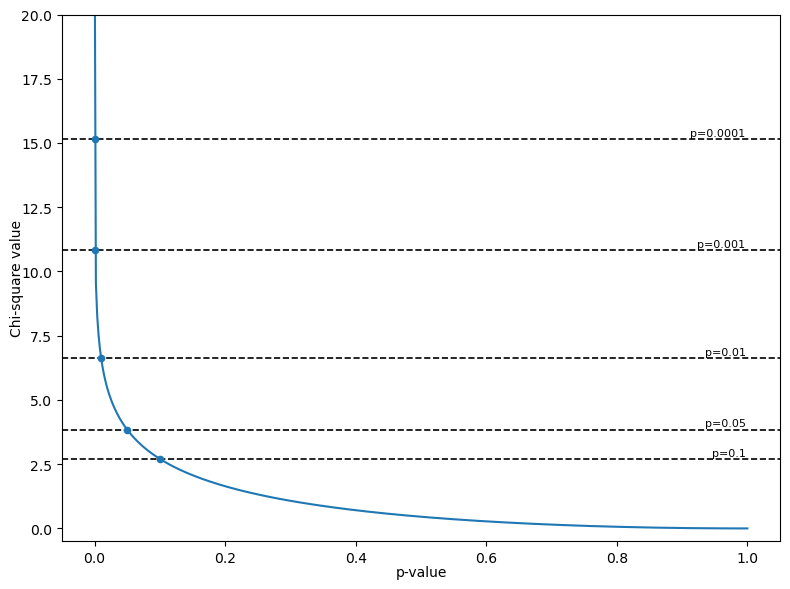

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# choose degrees of freedom
df = 1

# p-values from 0 to 1 (but avoid exactly 0)
p = np.linspace(0.000001, 0.9999, 500)
chi_vals = chi2.ppf(1 - p, df)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(p, chi_vals)

# special p-values
special_p = np.array([0.01, 0.05, 0.10, 0.001, 0.0001])
special_chi = chi2.ppf(1 - special_p, df)

# --- draw horizontal red dashed lines instead of dots ---
COMPARISON_LINES = list(zip(special_chi, [f"p={p}" for p in special_p]))

xmin, xmax = ax.get_xlim()

for yval, label in COMPARISON_LINES:
    ax.axhline(y=yval, color="black", ls="--", lw=1.2, alpha=1)
    ax.text(
        xmax * 0.95, yval + 0.05,
        label, color="black", fontsize=8, ha="right", va="bottom",
        backgroundcolor="white", alpha=1,
        zorder=-10
    )
special_p = np.array([0.01, 0.05, 0.10, 0.001, 0.0001])
special_chi = chi2.ppf(1 - special_p, df)

plt.scatter(special_p, special_chi, s=20, zorder=5)
ax.set_ylim(-0.5, 20)
# labels
ax.set_xlabel("p-value")
ax.xaxis.labelpad = 0
ax.set_ylabel("Chi-square value")
ax.yaxis.labelpad = -2
plt.tight_layout()
plt.savefig("notebooks/plots/chi_square_p_values.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()


In [69]:
def load_and_concat_multi_shift_files(folder_path, prefix, column_name_relevance, column_name_idx, multi_bias=False):
    import os
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    print("Found files:", shift_files)

    def parse_multi_bias_name(f):
        """Return (shift_value, idx_value, bias_type) from file name."""
        parts = f.replace('.csv', '').split('_')
        shift_value = float(parts[4])
        idx_value = int(parts[5].replace("idx", ""))

        # Extract bias_type
        bias_index = parts.index("bias")
        bias_type = "_".join(parts[bias_index + 1:])

        return shift_value, idx_value, bias_type

    if not multi_bias:
        # Sort by shift value, then by idx
        shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[-2].replace('.csv', '')))
        shift_files = sorted(shift_files, key=lambda x: int(x.split('idx')[-1].replace('.csv', '')))

        for idx, f in enumerate(shift_files):
            df = pd.read_csv(os.path.join(folder_path, f))
            df[column_name_relevance] = float(f.split('_')[-2].replace('.csv',''))
            df[column_name_idx] = int(f.split('idx')[-1].replace('.csv',''))
            if idx == 0:
                combined_df = df
            else:
                combined_df = pd.concat([combined_df, df], ignore_index=True)

    else:
        # Sort by: shift_value → idx → bias_type
        shift_files = sorted(shift_files, key=lambda f: parse_multi_bias_name(f))

        for idx, f in enumerate(shift_files):
            df = pd.read_csv(os.path.join(folder_path, f))
            shift_value, idx_value, bias_type = parse_multi_bias_name(f)

            df[column_name_relevance] = shift_value
            df[column_name_idx] = idx_value
            df["bias_type"] = bias_type[4:]

            if idx == 0:
                combined_df = df
            else:
                combined_df = pd.concat([combined_df, df], ignore_index=True)

    return combined_df


Found files: ['test_clicks_param_shift_-1.5_idx16_bias_typemedia_type.csv', 'test_clicks_param_shift_1.5_idx9_bias_typeposition.csv', 'test_clicks_param_shift_1.5_idx29_bias_typemedia_type.csv', 'test_clicks_param_shift_1.5_idx17_bias_typemedia_type.csv', 'test_clicks_param_shift_-1.5_idx28_bias_typemedia_type.csv', 'test_clicks_param_shift_-1.5_idx4_bias_typemedia_type.csv', 'test_clicks_param_shift_1.5_idx7_bias_typedisplayed_time.csv', 'test_clicks_param_shift_3.0_idx22_bias_typemedia_type.csv', 'test_clicks_param_shift_-3.0_idx6_bias_typemedia_type.csv', 'test_clicks_param_shift_1.5_idx11_bias_typeposition.csv', 'test_clicks_param_shift_1.5_idx9_bias_typemedia_type.csv', 'test_clicks_param_shift_-3.0_idx23_bias_typemedia_type.csv', 'test_clicks_param_shift_3.0_idx13_bias_typemedia_type.csv', 'test_clicks_param_shift_3.0_idx4_bias_typemedia_type.csv', 'test_clicks_param_shift_0.0_idx32_bias_typemedia_type.csv', 'test_clicks_param_shift_1.5_idx6_bias_typemedia_type.csv', 'test_clicks

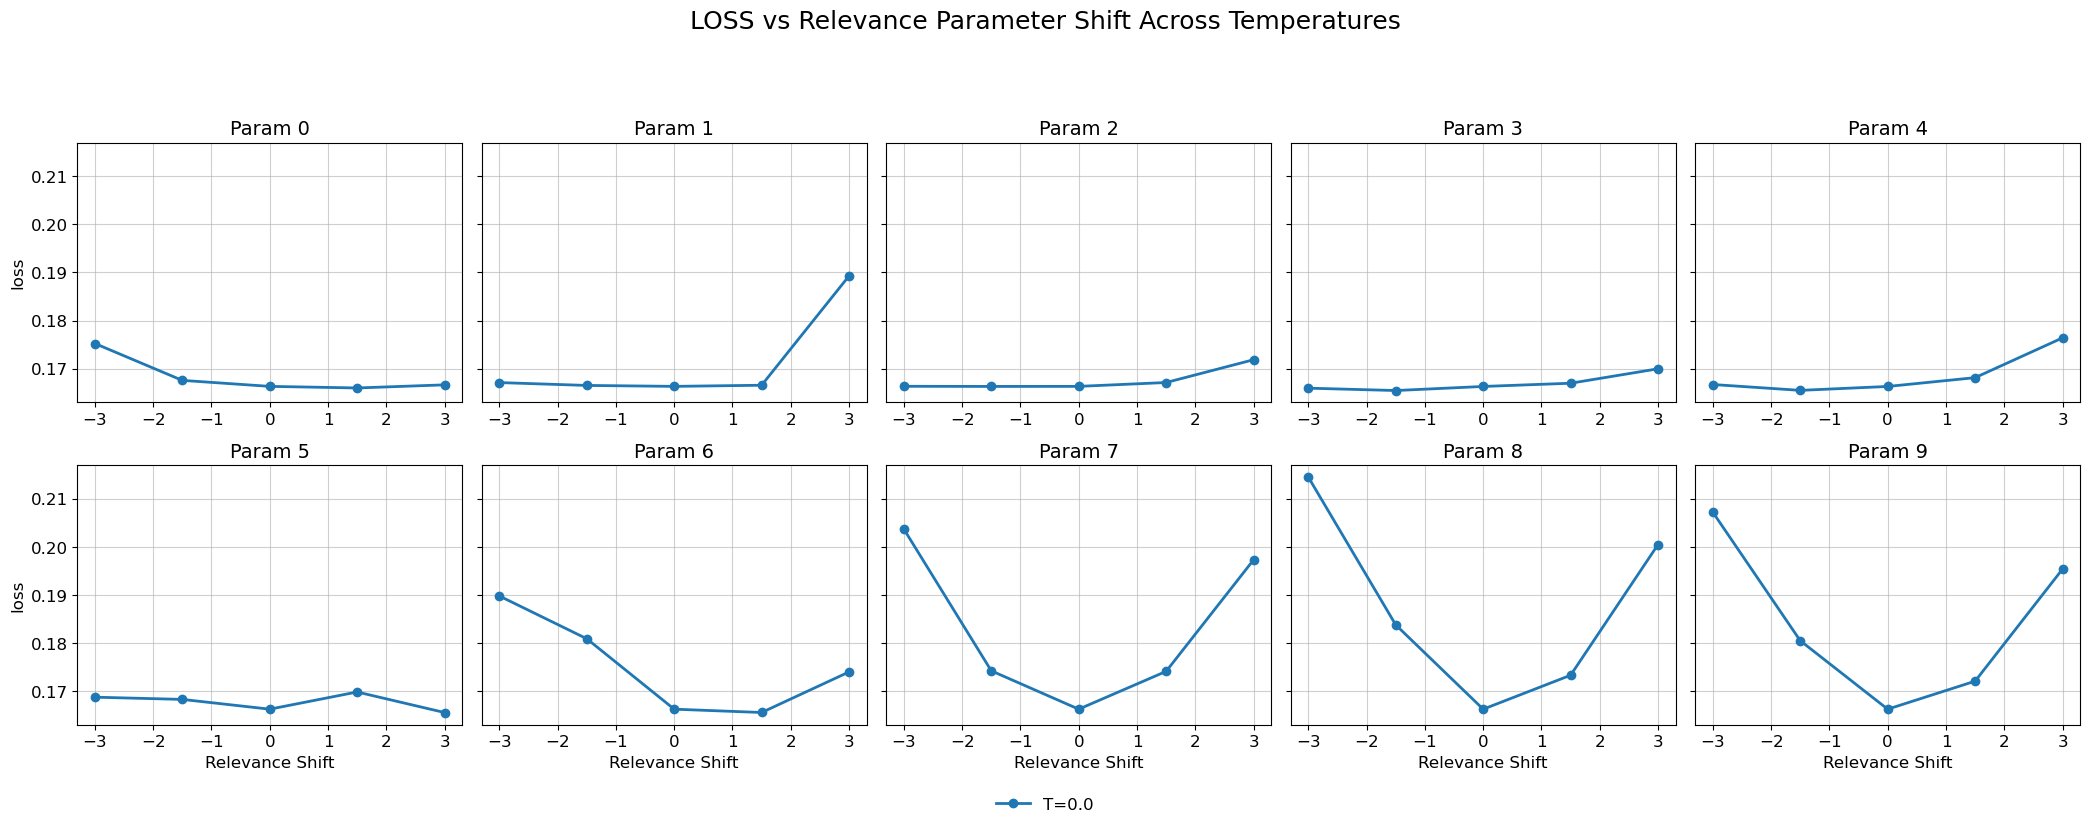

Plotting for bias type: media_type


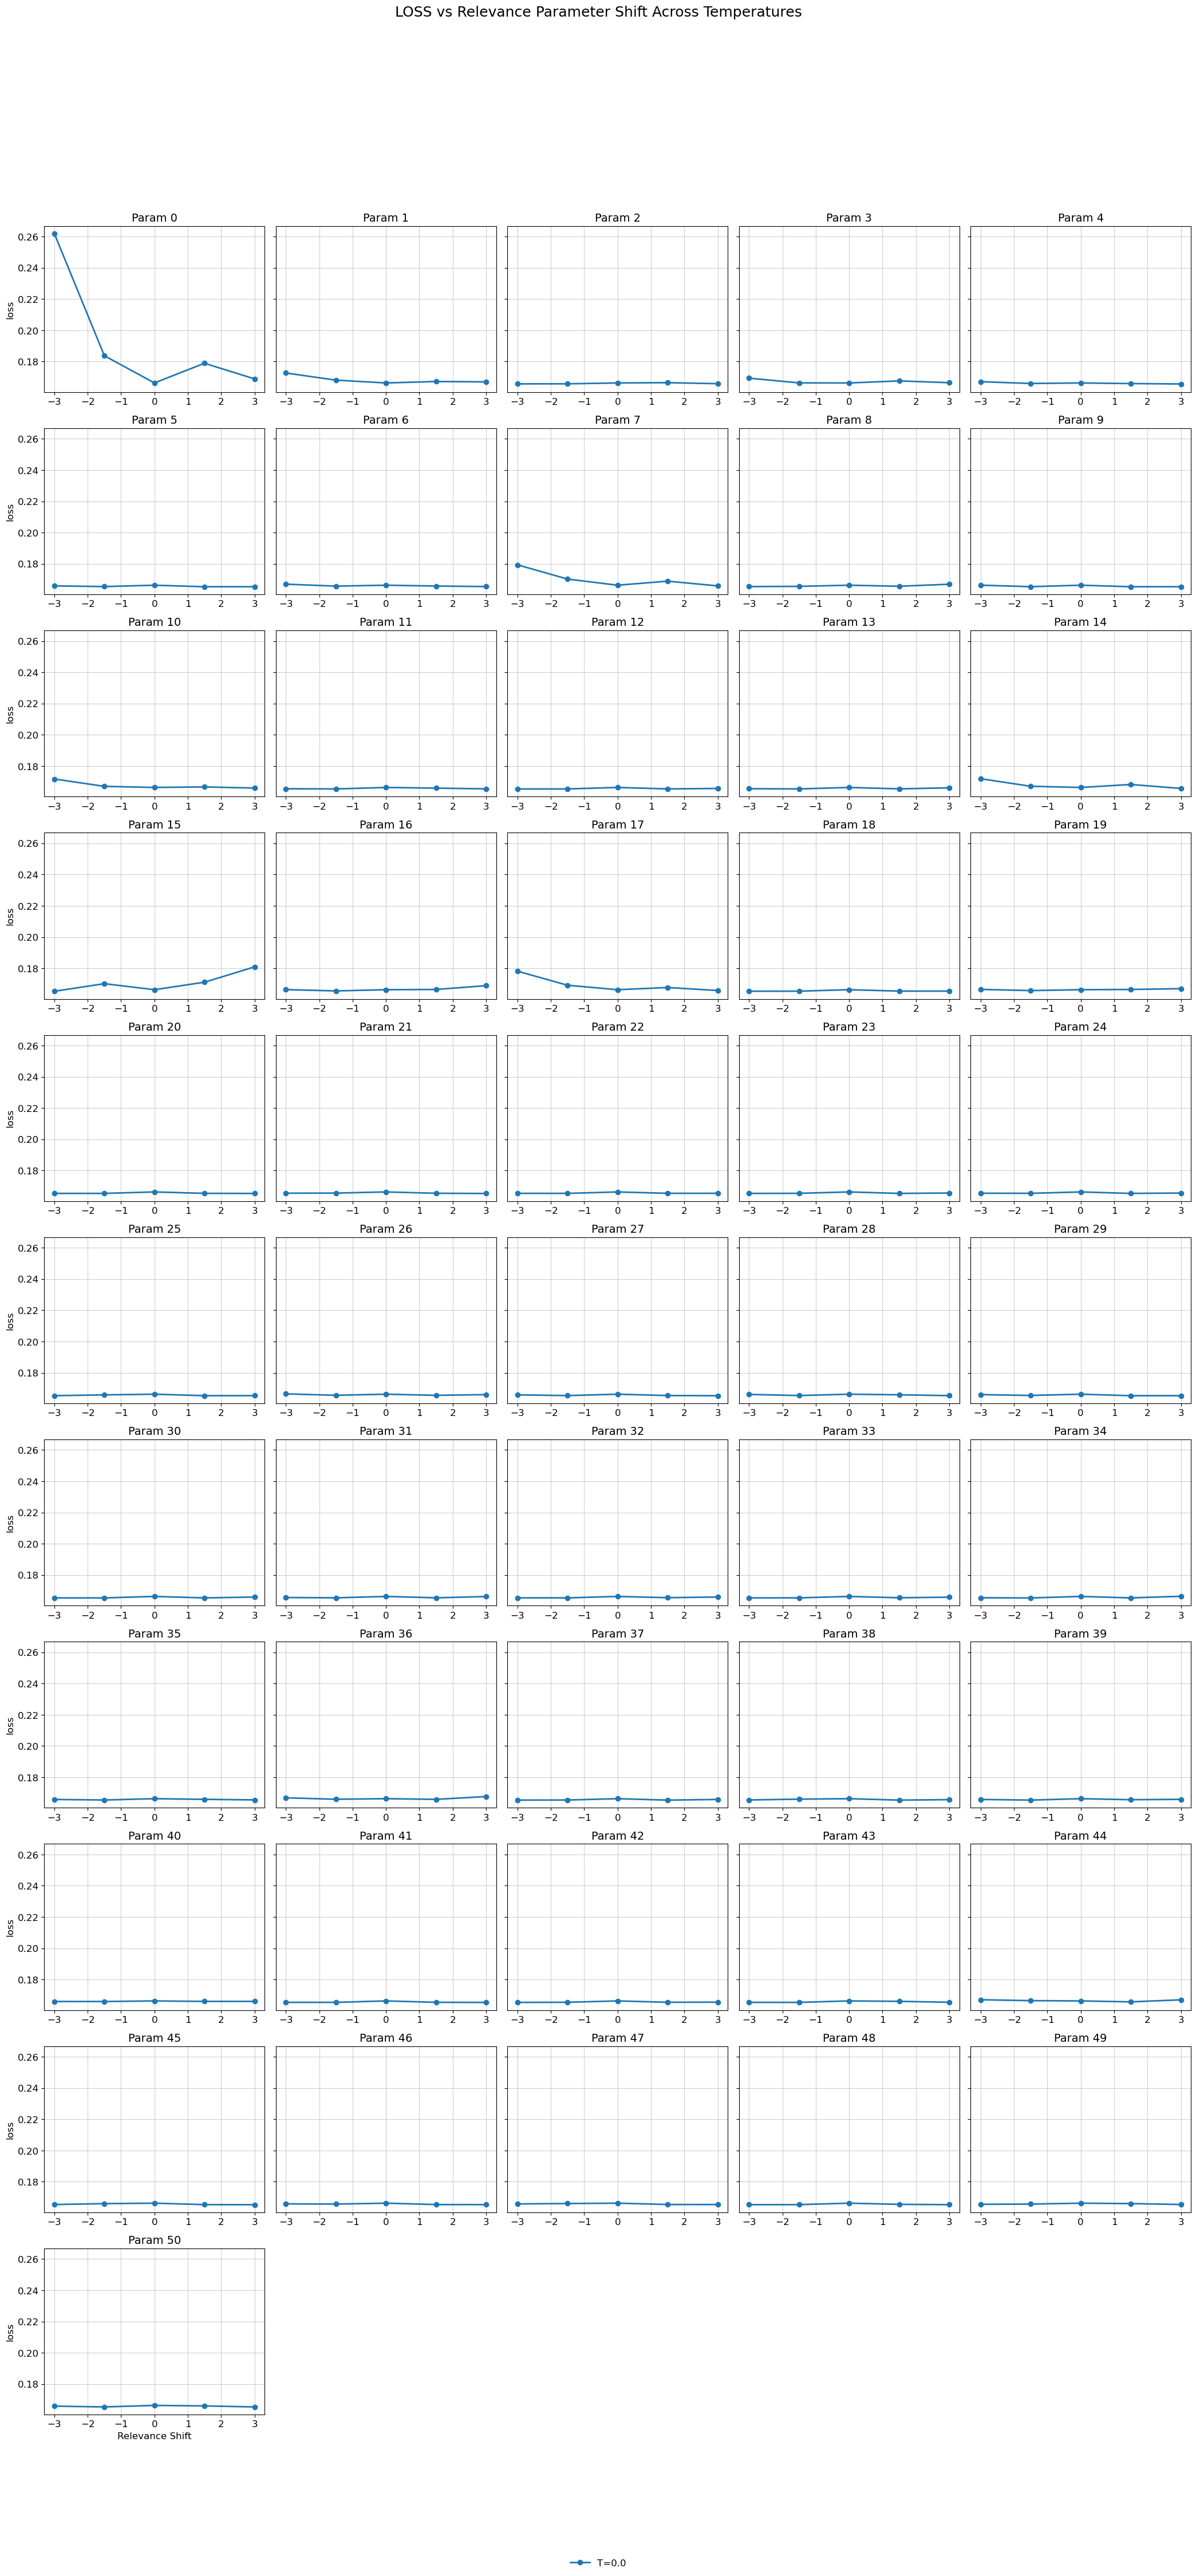

Plotting for bias type: position


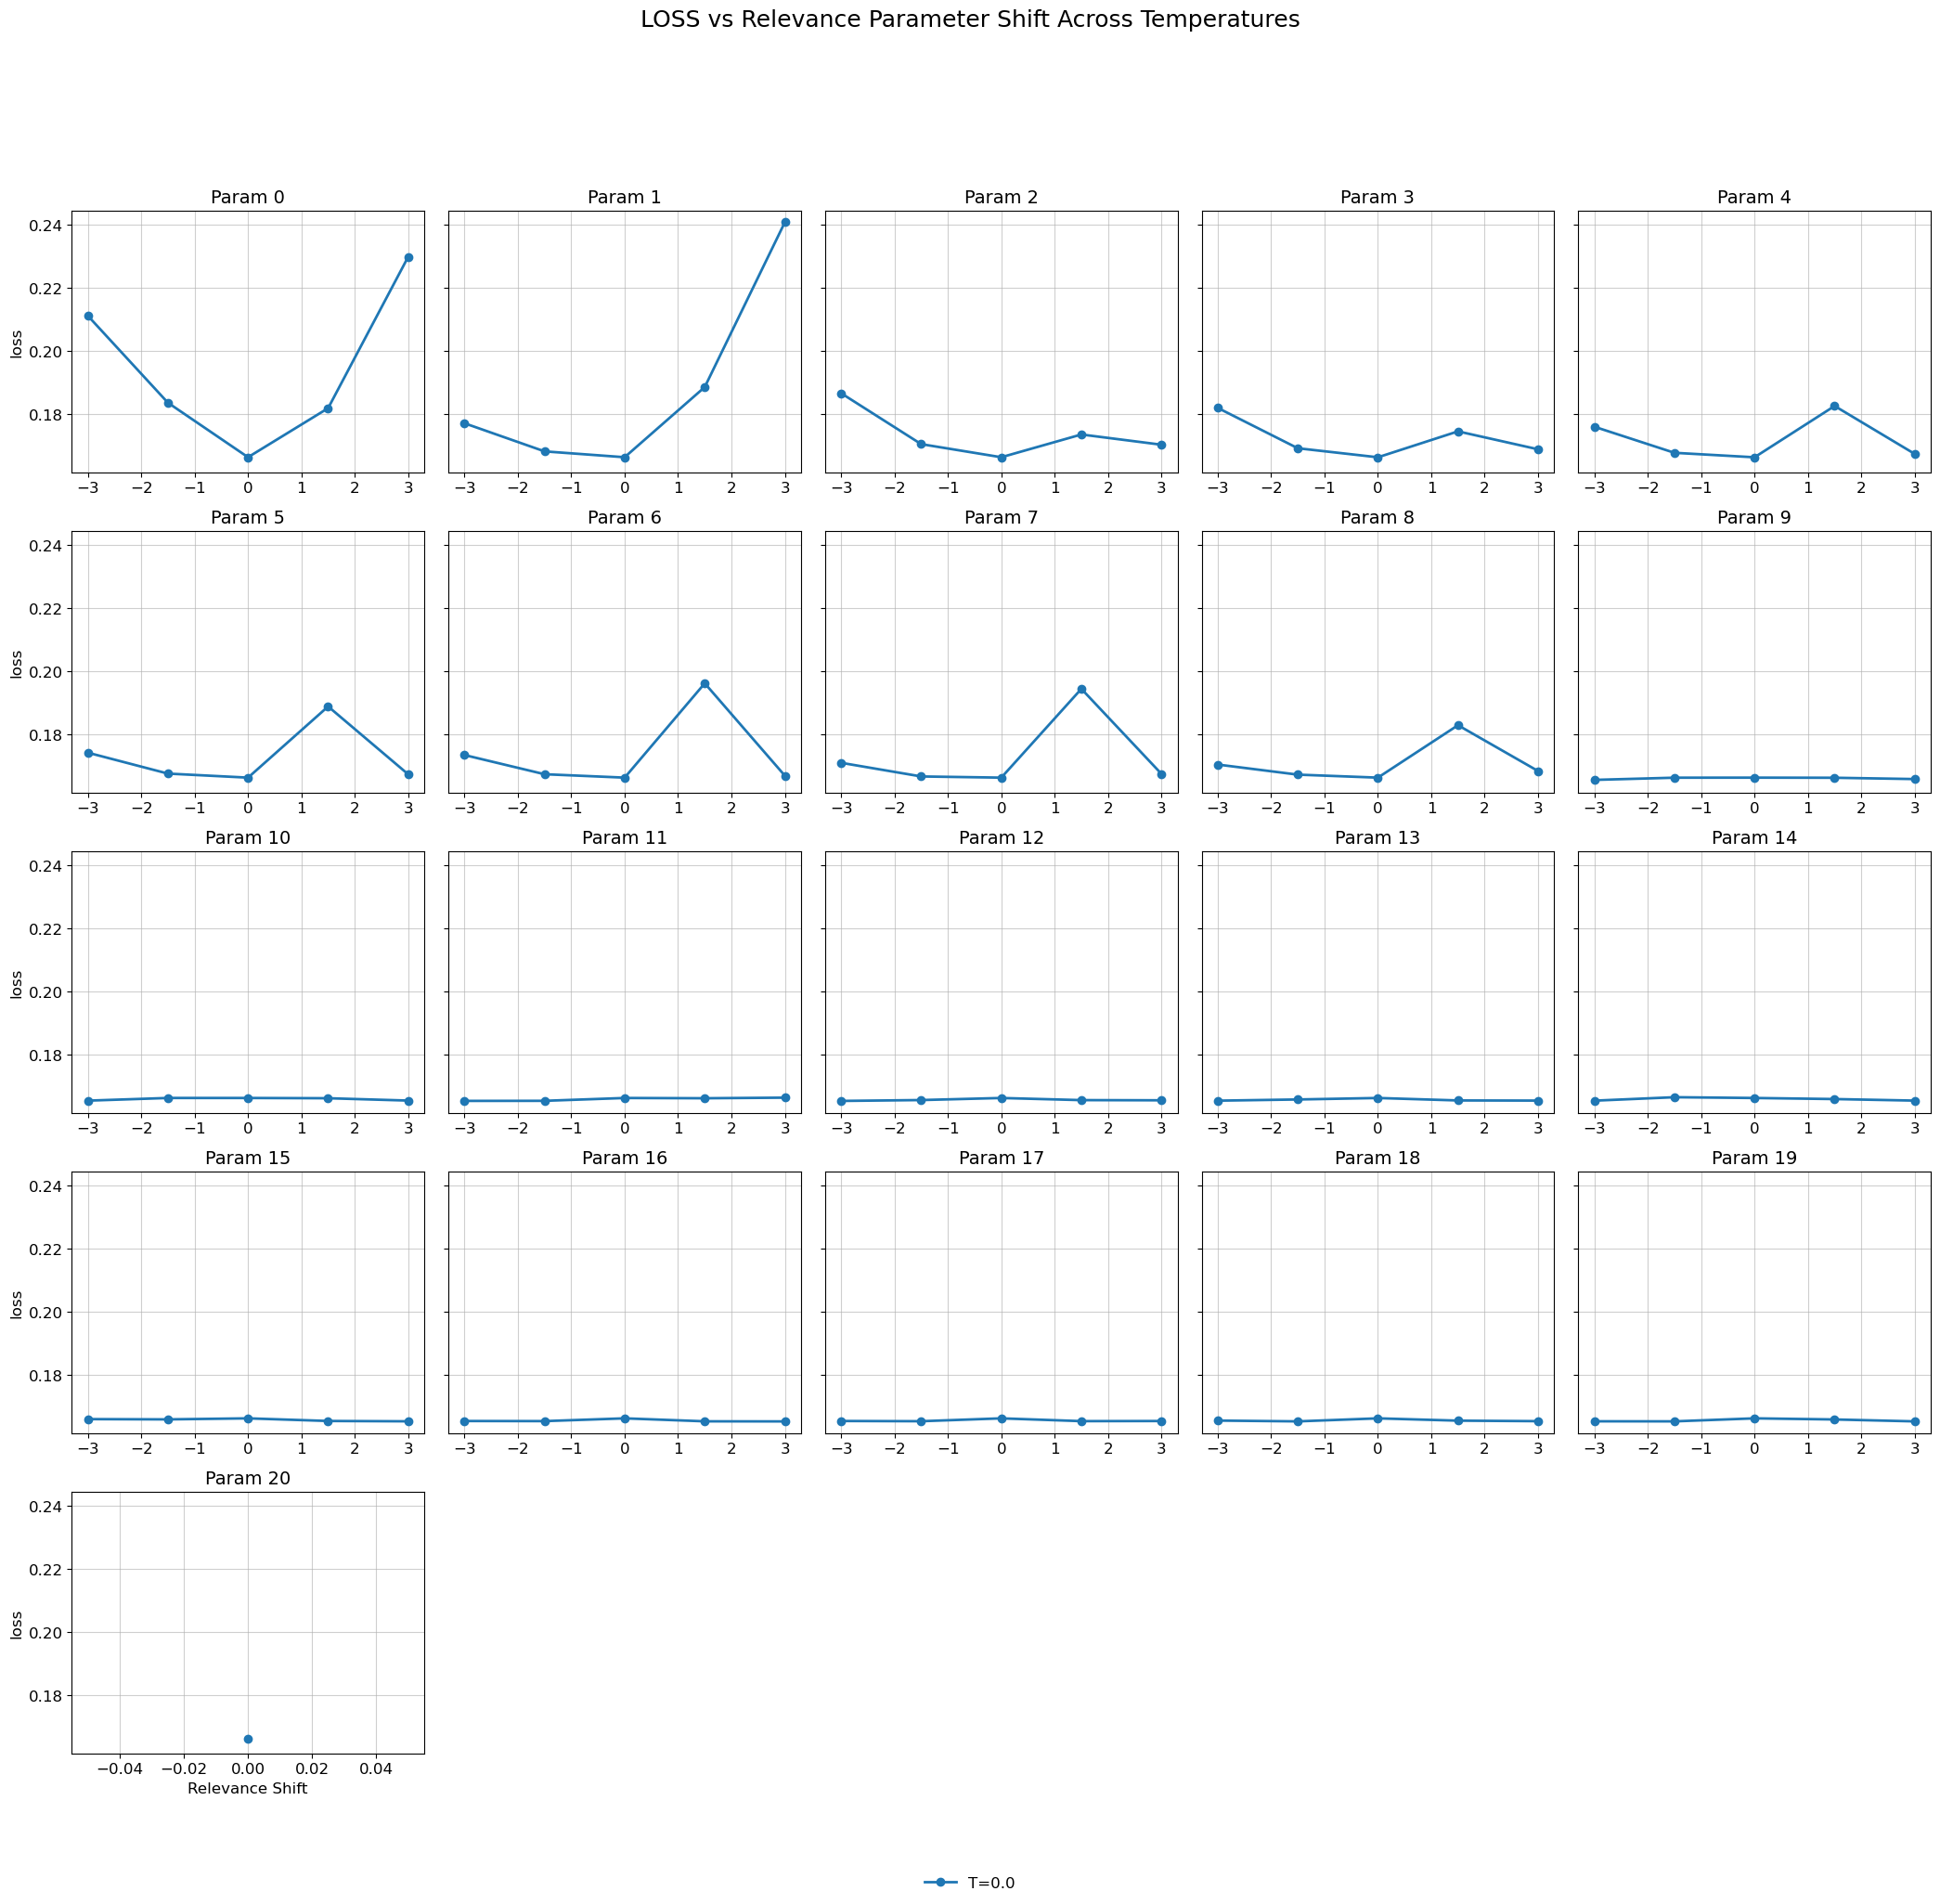

In [76]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

folder_path = "results/test_baidu/baidu_subset=train_Baidu_ULTRA_part1_multi_bias.npz,bias_tower=multi_embedding,data=Custom_dataset_deep,experiment=test_baidu,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,policy_temperature=0.0,relevance=deep,relevance_tower=deeper"


# Load performance (clicks)
perf_df = load_and_concat_multi_shift_files(
    folder_path,
    prefix_performance_clicks,
    'relevance_shift',
    'param_idx',
    multi_bias=True
)


# ✅ Now you can plot, just reversing the meaning of the axes
# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, doc_group_sizes, temperatures)
for bias_type in perf_df["bias_type"].unique():
    print(f"Plotting for bias type: {bias_type}")
    subset_df = perf_df[perf_df["bias_type"] == bias_type]
    plot_performance_grid_all_temps([subset_df], [0.0], metric='loss')

In [77]:
perf_df["bias_type"].unique()

array(['displayed_time', 'media_type', 'position'], dtype=object)

In [71]:
data = np.load("../ltr_datasets/train_Baidu_ULTRA_part1_multi_bias.npz", allow_pickle=True)
lp_feature_names = ["position", "media_type", "displayed_time", "serp_height", "slipoff_count_after_click"]

count_map = {}


for idx, lp_feature_name in enumerate(lp_feature_names):
    padded_positions = data['lp_query_doc_features'][:, :, idx].flatten()
    unique, counts = np.unique(padded_positions, return_counts=True)

    # each unique value corresponds to a param_idx used in the experiment
    for u, c in zip(unique, counts):
        if u == 0:
            count_map[(lp_feature_name, int(u))] = int(c) - np.logical_not(data['mask']).sum()
        else:
            count_map[(lp_feature_name, int(u))] = int(c)

# Now apply context-dependent mapping
perf_df["sample_count"] = perf_df.apply(
    lambda row: count_map.get((row["bias_type"], row["param_idx"]), np.nan),
    axis=1
)


Identifiability results for bias type: displayed_time
Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     3.0 |   0.002038 | 2422655.0 |             identified
    1 |  0.0001 |    -1.5 |     1.5 |   0.004843 | 2422660.0 |             identified
    2 |   0.001 |    -3.0 |     1.5 |   0.001279 | 2422660.0 |             identified
    3 |    None |    None |     1.5 |   0.000622 | 2422655.0 | practically unidentified
    4 |  0.0001 |    -3.0 |     1.5 |   0.002296 | 2422660.0 |             identified
    5 |  0.0001 |    -1.5 |     1.5 |   0.001474 | 2422660.0 |             identified
    6 |  0.0001 |    -1.5 |     3.0 |   0.009031 | 2422655.0 |             identified
    7 |  0.0001 |    -1.5 |     1.5 |   0.016839 | 2422660.0 |             identified
    8 |  0.0001 |    -1.5 |     1.5 |   0.021378 | 2422660.0 |            

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_15229/2299770791.py:271: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


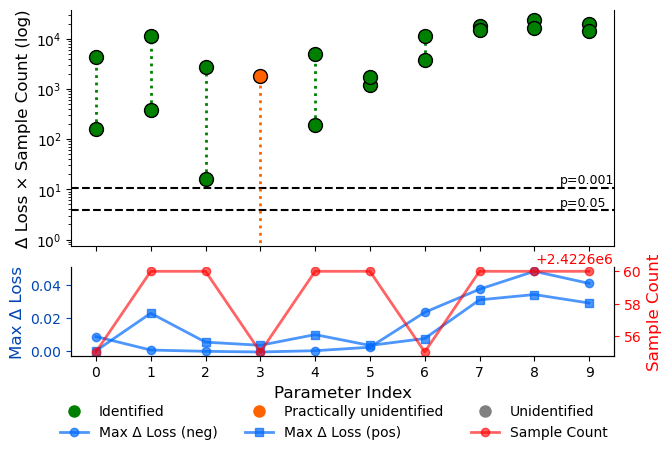


Identifiability results for bias type: media_type
Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     1.5 |   0.025649 | 16656010.0 |             identified
    1 |  0.0001 |    -1.5 |     1.5 |   0.001966 | 287335.0 |             identified
    2 |    None |    None |    None |  -0.000273 |  15180.0 |           unidentified
    3 |  0.0001 |    -3.0 |     1.5 |   0.000923 | 185760.0 |             identified
    4 |    0.05 |    -3.0 |    None |  -0.000108 |  58665.0 | practically unidentified
    5 |    None |    None |    None |  -0.000646 |   9080.0 |           unidentified
    6 |   0.001 |    -3.0 |    None |  -0.000260 | 110115.0 | practically unidentified
    7 |  0.0001 |    -1.5 |     1.5 |   0.003824 | 704600.0 |             identified
    8 |    None |    None |     3.0 |  -0.000329 |  43560.0 | practically unidenti

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_15229/2299770791.py:271: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


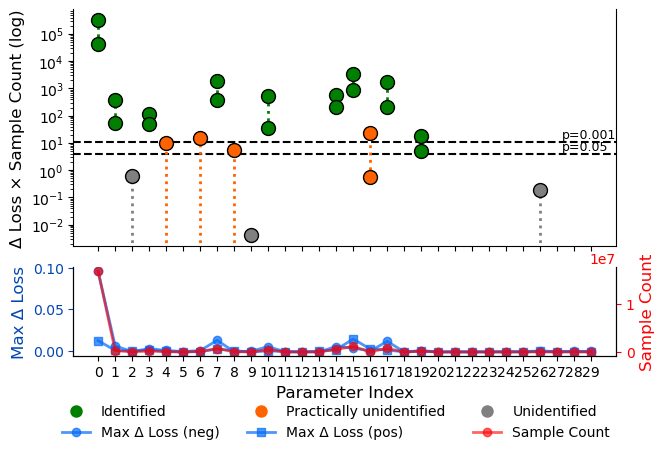


Identifiability results for bias type: position
Param |   Neg p |   Neg Δ |   Pos Δ |  Avg ΔLoss |  Samples |             Conclusion
-----------------------------------------------------------------------------------------------
    0 |  0.0001 |    -1.5 |     1.5 |   0.028237 | 2500800.0 |             identified
    1 |  0.0001 |    -1.5 |     1.5 |   0.021867 | 2427380.0 |             identified
    2 |  0.0001 |    -1.5 |     1.5 |   0.007135 | 2578605.0 |             identified
    3 |  0.0001 |    -1.5 |     1.5 |   0.005847 | 2572430.0 |             identified
    4 |  0.0001 |    -1.5 |     1.5 |   0.005683 | 2593235.0 |             identified
    5 |  0.0001 |    -1.5 |     1.5 |   0.006556 | 2624270.0 |             identified
    6 |  0.0001 |    -1.5 |     1.5 |   0.007750 | 2747285.0 |             identified
    7 |  0.0001 |    -1.5 |     1.5 |   0.006878 | 2606520.0 |             identified
    8 |  0.0001 |    -1.5 |     1.5 |   0.004758 | 2782985.0 |             identif

/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_15229/1413385744.py:46: RuntimeWarning: invalid value encountered in scalar divide
  sub["delta_loss_times_samples"].sum() /
/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_15229/2299770791.py:271: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


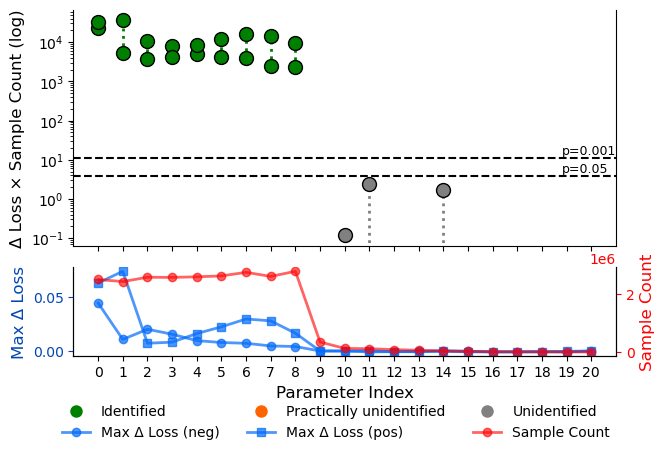

In [72]:
from scipy.stats import chi2

# Usage
perf_df=perf_df[perf_df["param_idx"] < 30]
for bias_type in perf_df.bias_type.unique():
    subset_df = perf_df.loc[perf_df["bias_type"] == bias_type].copy()  # <--- FIX

    baseline_loss = perf_df.loc[perf_df["relevance_shift"] == 0, "loss"].mean()
    perf_df["delta_loss"] = perf_df["loss"] - baseline_loss
    perf_df["delta_loss_times_samples"] = perf_df["delta_loss"] * perf_df["sample_count"]

    # Compute global delta loss first
    baseline_loss = subset_df.loc[subset_df["relevance_shift"] == 0, "loss"].mean()

    subset_df["delta_loss"] = subset_df["loss"] - baseline_loss
    subset_df["delta_loss_times_samples"] = subset_df["delta_loss"] * subset_df["sample_count"]
    print(f"\nIdentifiability results for bias type: {bias_type}")
    identifiability_results = compute_identifiability(
        subset_df,
        thresholds=[0.05, 0.001, 0.0001]
    )

    _, _, = plot_identifiability_summary(
    identifiability_results,
    perf_df[perf_df["bias_type"] == bias_type],
    output_path=None,
    )

